In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Heart Disease EDA - Simple and Clean

File: `heart.csv` has 918 rows and 12 columns. Target is `HeartDisease` (0 = No, 1 = Yes).

In [68]:
# Load data and see basic shape
df = pd.read_csv('heart.csv')
print(df.shape)
print(list(df.columns))
df.head()

(918, 12)
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [69]:
# Data types and summary
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [70]:
# 1. Check missing values and duplicates
# No missing values here, but we still check
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
print(df.nunique())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Duplicates: 0
Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64


In [71]:
# 2. Zero means missing for these two columns
# RestingBP and Cholesterol can never be 0 in real life
print('RestingBP = 0:', (df['RestingBP'] == 0).sum())
print('Cholesterol = 0:', (df['Cholesterol'] == 0).sum())
print('Cholesterol 0 %:', round((df['Cholesterol'] == 0).mean() * 100, 1))
print(pd.crosstab(df['Cholesterol'] == 0, df['HeartDisease']))

RestingBP = 0: 1
Cholesterol = 0: 172
Cholesterol 0 %: 18.7
HeartDisease    0    1
Cholesterol           
False         390  356
True           20  152


## Target: HeartDisease

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64


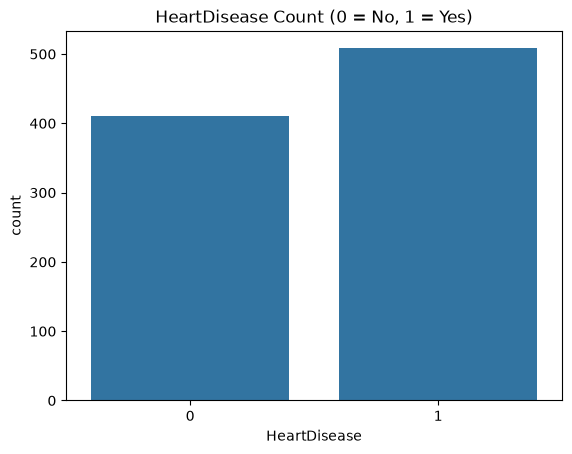

In [72]:
# 3. How many sick vs healthy?
print(df['HeartDisease'].value_counts())
print((df['HeartDisease'].value_counts(normalize=True) * 100).round(1))

sns.countplot(data=df, x='HeartDisease')
plt.title('HeartDisease Count (0 = No, 1 = Yes)')
plt.show()

## Numbers: distribution

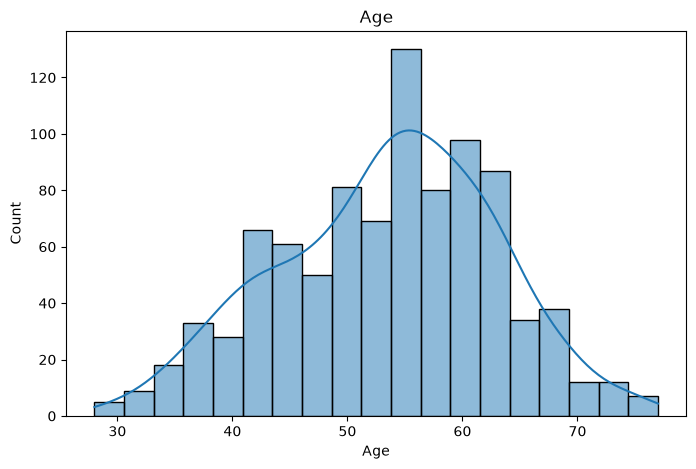

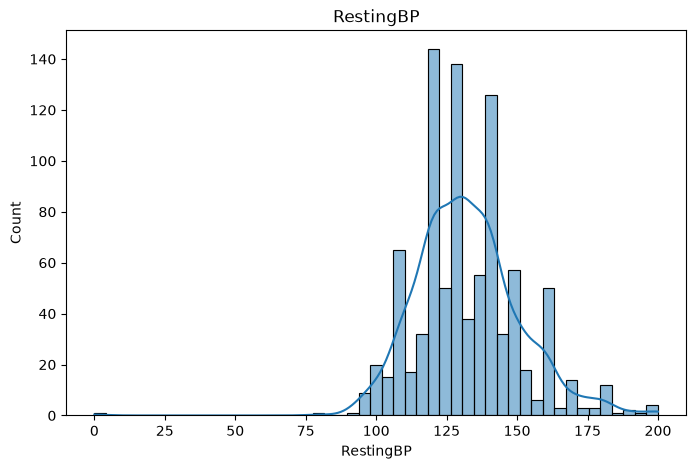

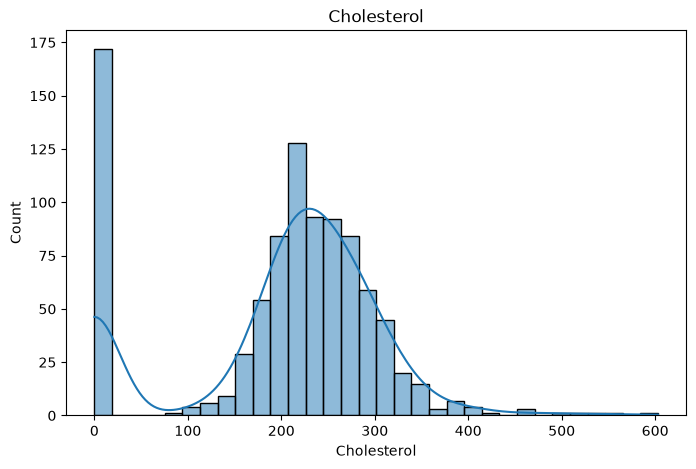

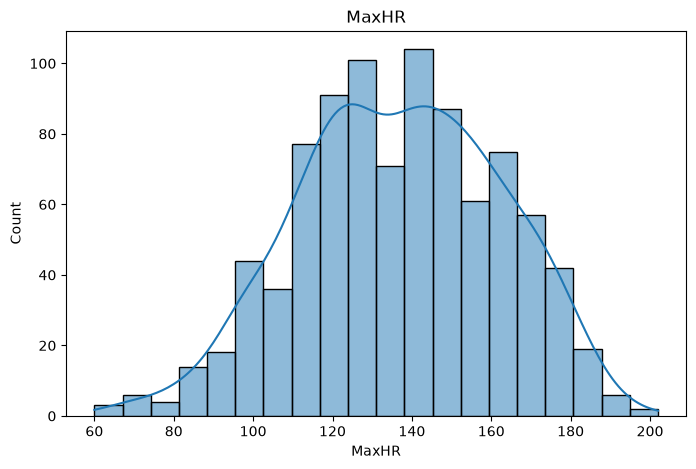

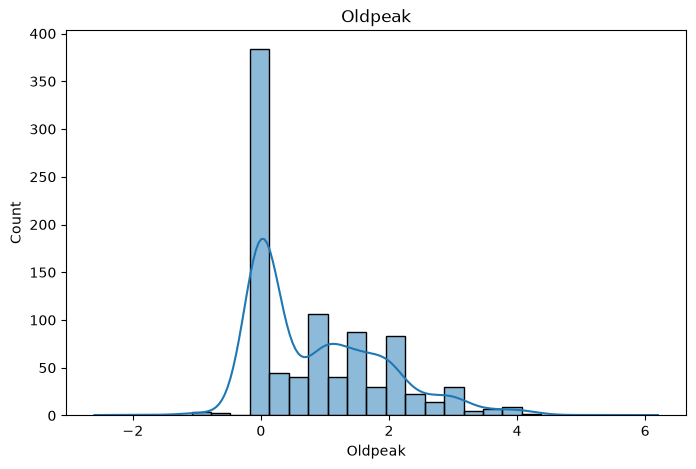

In [73]:
# 4. See each number column one by one
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

## Text columns: distribution

Sex
Sex
M    725
F    193
Name: count, dtype: int64


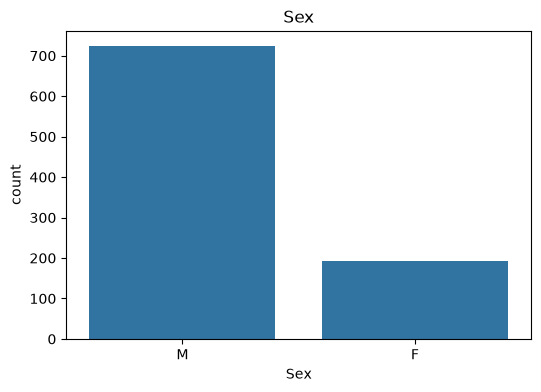

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


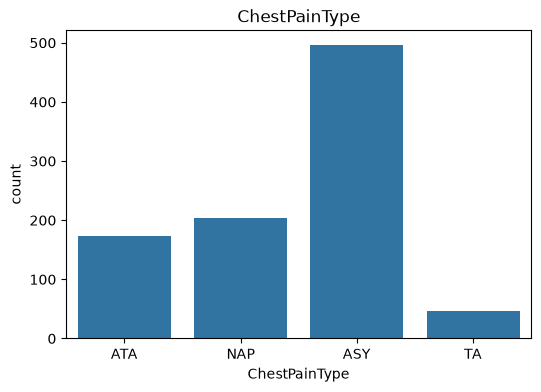

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


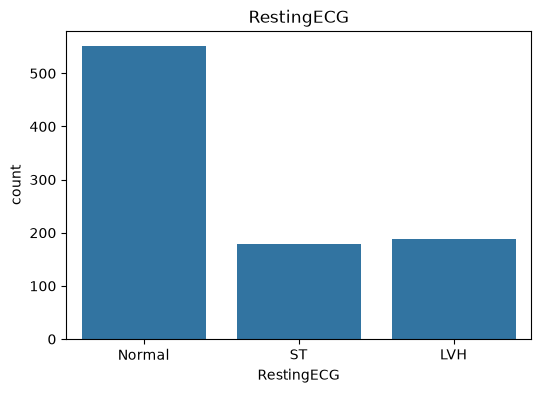

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


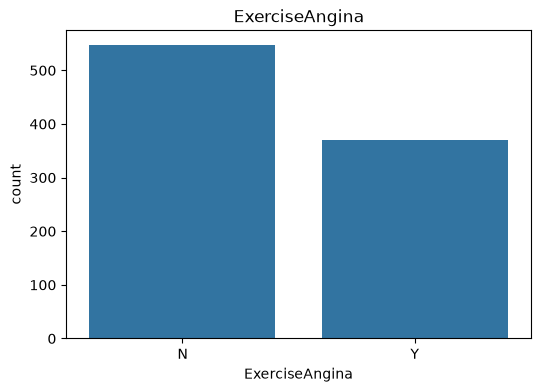

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


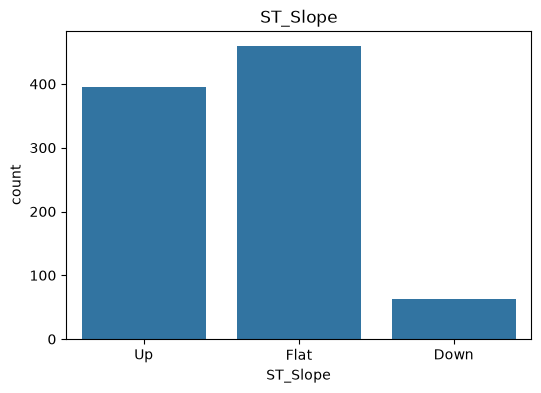

In [74]:
# 5. See each text column one by one
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.show()

## Numbers vs Target

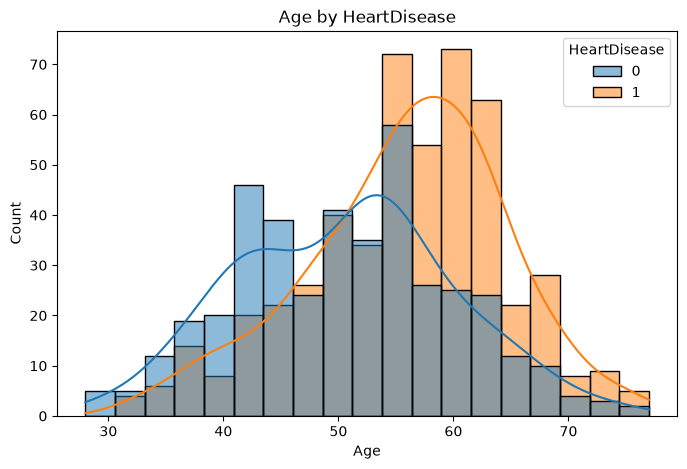

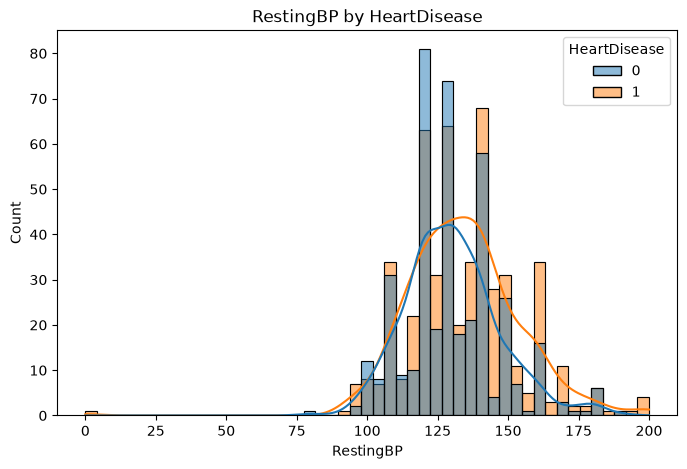

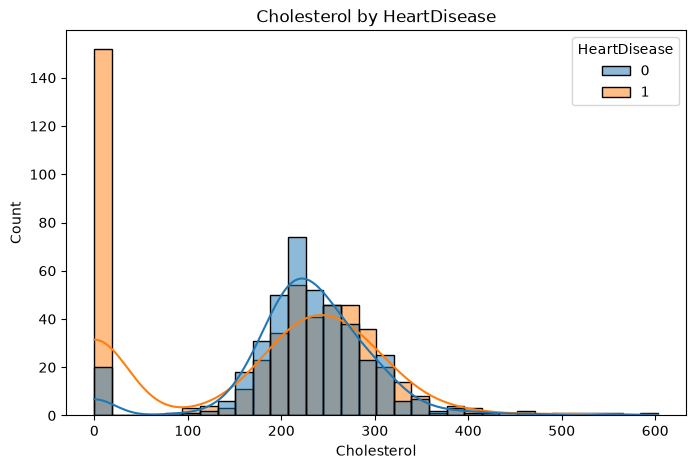

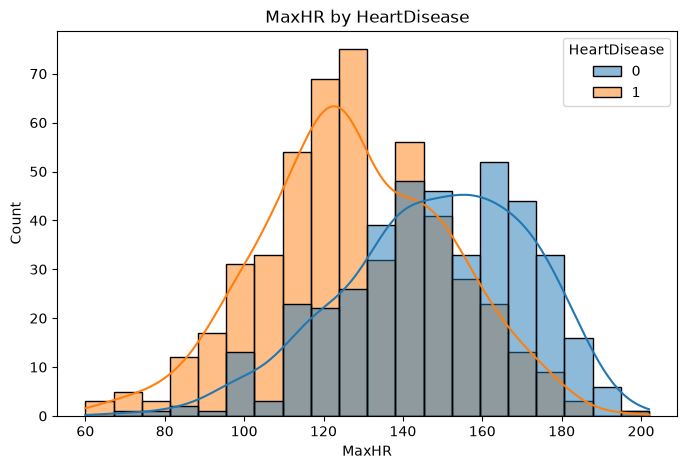

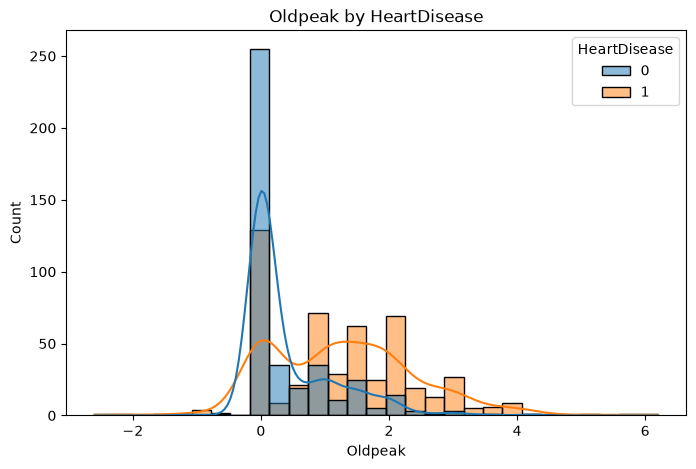

In [75]:
# 6. Do sick people have different numbers?
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True)
    plt.title(col + ' by HeartDisease')
    plt.show()

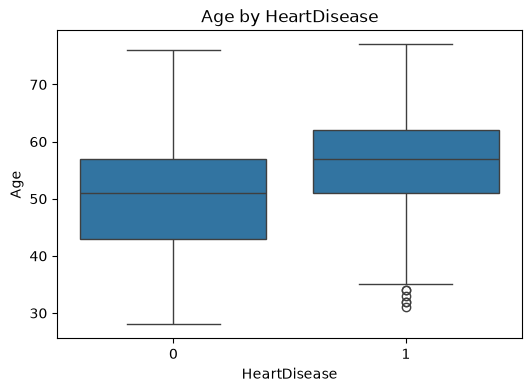

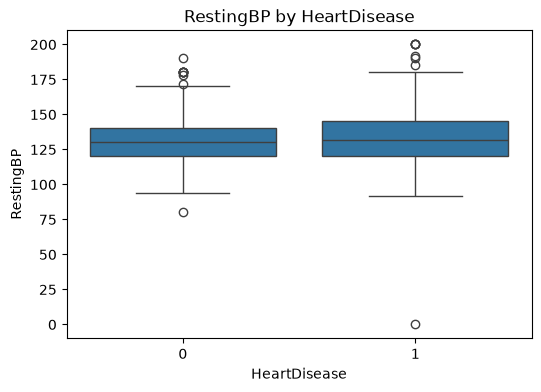

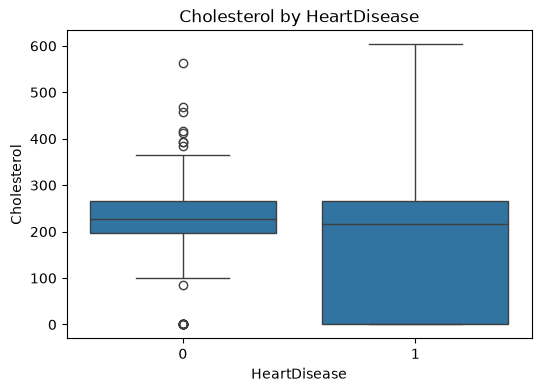

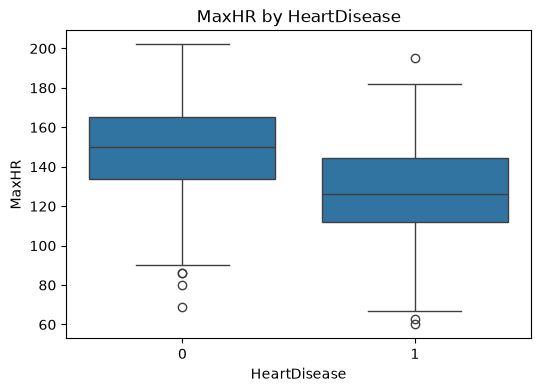

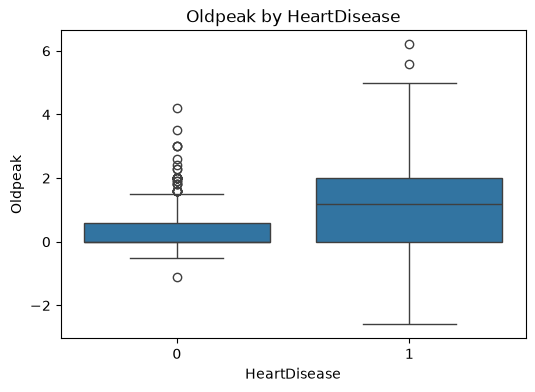

In [76]:
# Same thing with boxplot. Easy to see median difference.
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='HeartDisease', y=col)
    plt.title(col + ' by HeartDisease')
    plt.show()

In [77]:
# Average numbers for sick vs healthy
print(df.groupby('HeartDisease')[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']].mean().round(1))

               Age  RestingBP  Cholesterol  MaxHR  Oldpeak
HeartDisease                                              
0             50.6      130.2        227.1  148.2      0.4
1             55.9      134.2        175.9  127.7      1.3


## Text columns vs Target

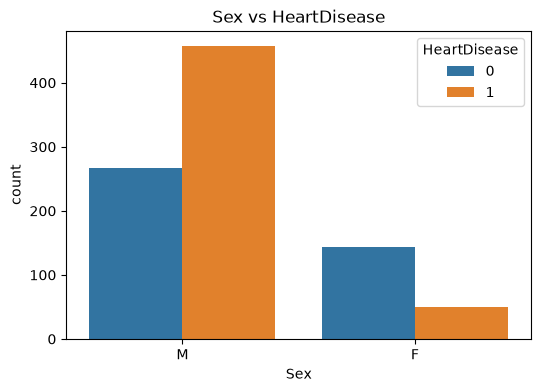

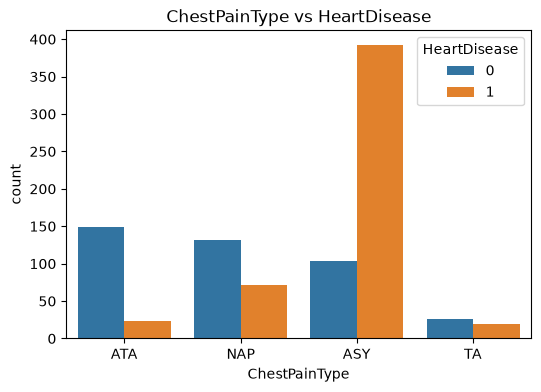

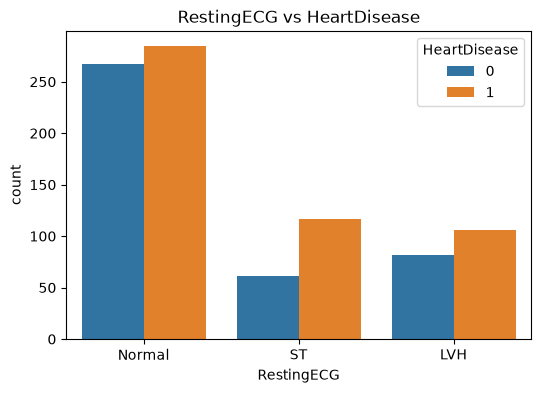

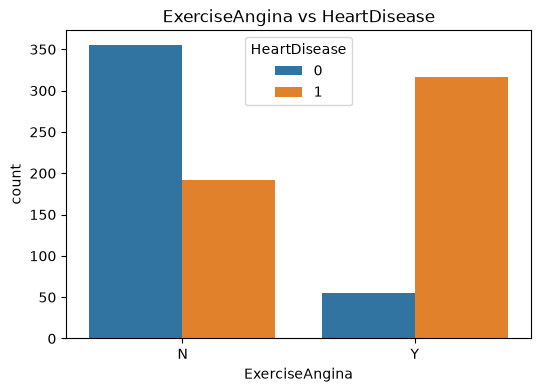

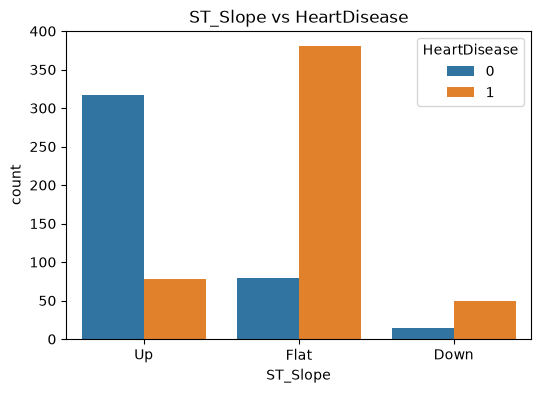

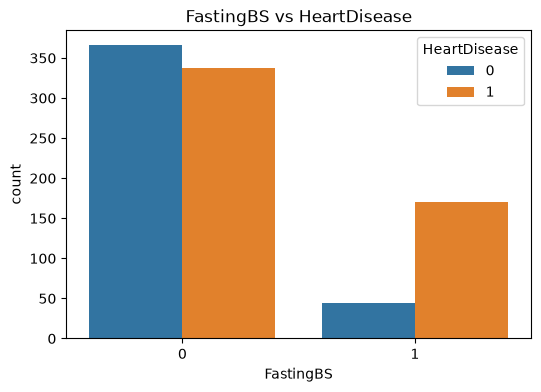

In [78]:
# 7. Which group is more sick?
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(col + ' vs HeartDisease')
    plt.show()

In [79]:
# Disease rate. Mean = share of sick. 0.8 = 80% sick.
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    print(col)
    print((df.groupby(col, observed=True)['HeartDisease'].mean()).round(3))

Sex
Sex
F    0.259
M    0.632
Name: HeartDisease, dtype: float64
ChestPainType
ChestPainType
ASY    0.790
ATA    0.139
NAP    0.355
TA     0.435
Name: HeartDisease, dtype: float64
RestingECG
RestingECG
LVH       0.564
Normal    0.516
ST        0.657
Name: HeartDisease, dtype: float64
ExerciseAngina
ExerciseAngina
N    0.351
Y    0.852
Name: HeartDisease, dtype: float64
ST_Slope
ST_Slope
Down    0.778
Flat    0.828
Up      0.197
Name: HeartDisease, dtype: float64
FastingBS
FastingBS
0    0.480
1    0.794
Name: HeartDisease, dtype: float64


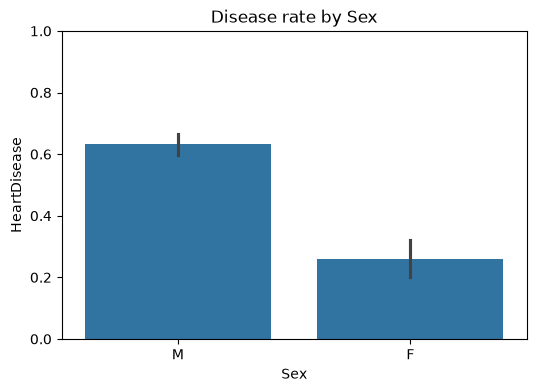

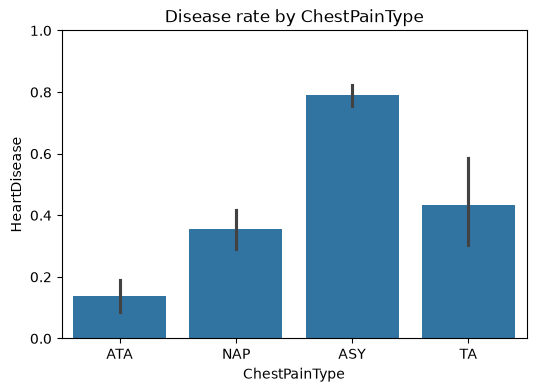

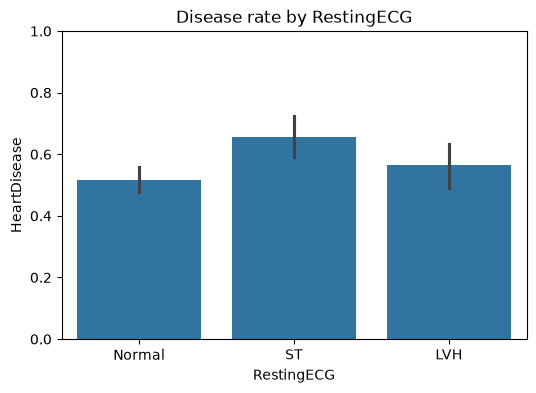

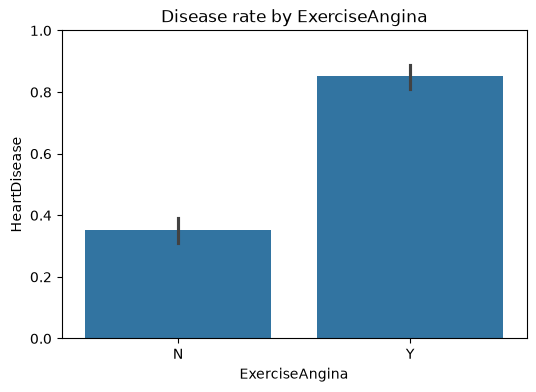

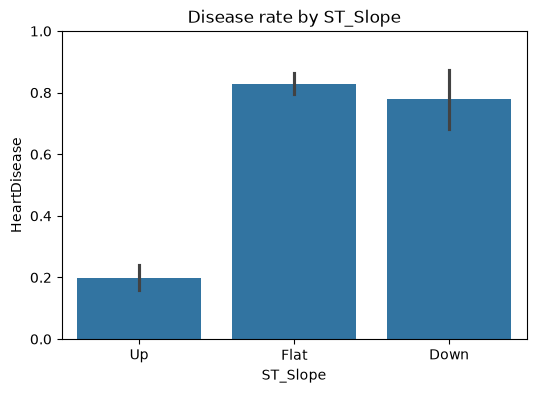

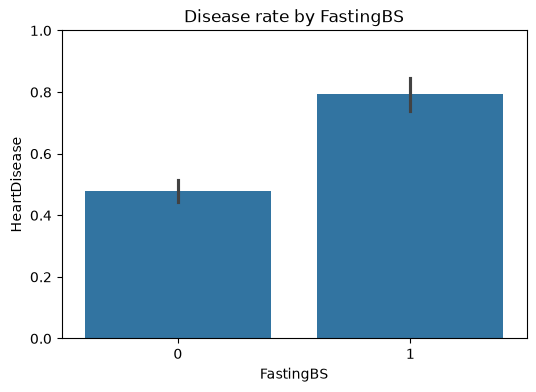

In [80]:
# Disease rate bar plot. This is better than sum.
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=col, y='HeartDisease')
    plt.ylim(0, 1)
    plt.title('Disease rate by ' + col)
    plt.show()

## Important: Cholesterol zero problem

In [81]:
# Cholesterol 0 rows are mostly sick, so average looks wrong
print('With zeros:')
print(df.groupby('HeartDisease')['Cholesterol'].mean().round(1))

print('Without zeros:')
df_good = df[df['Cholesterol'] > 0]
print(df_good.groupby('HeartDisease')['Cholesterol'].mean().round(1))
print('Without zeros, sick group has higher cholesterol. This makes sense.')

With zeros:
HeartDisease
0    227.1
1    175.9
Name: Cholesterol, dtype: float64
Without zeros:
HeartDisease
0    238.8
1    251.1
Name: Cholesterol, dtype: float64
Without zeros, sick group has higher cholesterol. This makes sense.


## Outliers: simple check

In [82]:
# Simple IQR rule to count outliers
for col in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(col, 'skew:', round(df[col].skew(), 2), 'outliers:', n_out)

Age skew: -0.2 outliers: 0
RestingBP skew: 0.18 outliers: 28
Cholesterol skew: -0.61 outliers: 183
MaxHR skew: -0.14 outliers: 2
Oldpeak skew: 1.02 outliers: 16


## Correlation

HeartDisease    1.000
Oldpeak         0.404
Age             0.282
FastingBS       0.267
RestingBP       0.108
Cholesterol    -0.233
MaxHR          -0.400
Name: HeartDisease, dtype: float64


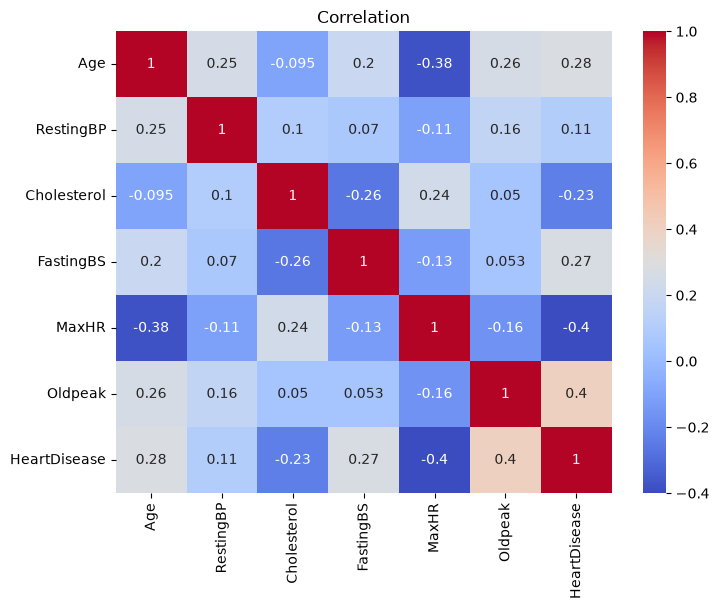

In [83]:
# Which numbers go up or down with disease?
corr = df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']].corr()
print(corr['HeartDisease'].sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

## Groups and best combination

AgeGroup
<40      0.344
40-50    0.417
50-60    0.583
60+      0.729
Name: HeartDisease, dtype: float64


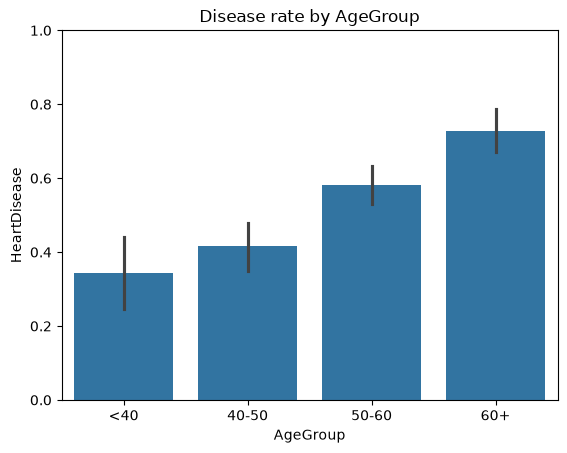

In [84]:
# Older people are more sick
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], labels=['<40', '40-50', '50-60', '60+'])
print(df.groupby('AgeGroup', observed=True)['HeartDisease'].mean().round(3))

sns.barplot(data=df, x='AgeGroup', y='HeartDisease')
plt.ylim(0, 1)
plt.title('Disease rate by AgeGroup')
plt.show()

OldpeakBin
<=0    0.349
0-1    0.520
1-2    0.764
>2     0.910
Name: HeartDisease, dtype: float64


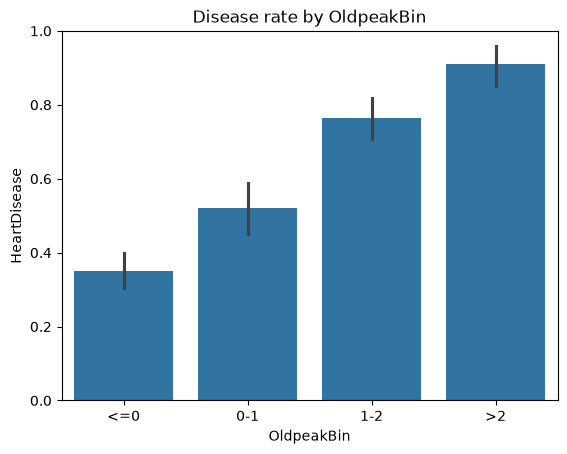

In [85]:
# Higher Oldpeak means more sick
df['OldpeakBin'] = pd.cut(df['Oldpeak'], bins=[-3, 0, 1, 2, 7], labels=['<=0', '0-1', '1-2', '>2'])
print(df.groupby('OldpeakBin', observed=True)['HeartDisease'].mean().round(3))

sns.barplot(data=df, x='OldpeakBin', y='HeartDisease')
plt.ylim(0, 1)
plt.title('Disease rate by OldpeakBin')
plt.show()

ST_Slope       Down  Flat    Up
ChestPainType                  
ASY            0.91  0.91  0.46
ATA            0.33  0.56  0.04
NAP            0.50  0.67  0.08
TA             0.25  0.68  0.20


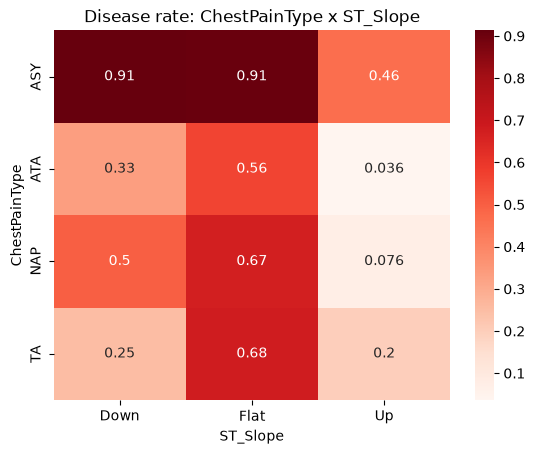

ASY + Flat = ~0.91 sick. ATA + Up = ~0.04 sick.


In [86]:
# Best combination: ChestPainType + ST_Slope
table = pd.crosstab(df['ChestPainType'], df['ST_Slope'], values=df['HeartDisease'], aggfunc='mean')
print(table.round(2))

sns.heatmap(table, annot=True, cmap='Reds')
plt.title('Disease rate: ChestPainType x ST_Slope')
plt.show()
print('ASY + Flat = ~0.91 sick. ATA + Up = ~0.04 sick.')

## Summary

- 918 rows, no missing values, no duplicates.
- Target: 55.3% sick, 44.7% healthy.
- Cholesterol 0 in 172 rows (18.7%). Treat as missing.
- High risk: ASY, Flat slope, ExerciseAngina Y, FastingBS 1, Male, older age, low MaxHR, high Oldpeak.
- Low risk: ATA, Up slope, ExerciseAngina N.